In [11]:
%reset -f
import sys
sys.path.append("/Users/lingyi/Documents/spatial/colocalization/functions")
import importlib
import tools
importlib.reload(tools)
import os


import spatialdata_io
import scanpy as sc
import numpy as np
import pandas as pd
from scipy import stats


from spatialdata_io._constants._constants import VisiumHDKeys
from spatialdata.models import Image2DModel, ShapesModel, TableModel
from spatialdata.transformations import Affine, Identity, Scale, set_transformation
import json
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from scipy import sparse

Ranked by CD3D ranking 
1. HRA002509_lung/raw/ST-visium_new_P19: median rank = 447.0
2. GSE210616_breast_spatial_GSM6433623_397D: median rank = 768.0
3. GSE210616_breast_spatial_GSM6433609_120B: median rank = 1095.0

/Users/lingyi/Documents/spatial/colocalization/functions/tools.py:175: FutureWarning: Use `squidpy.read.visium` instead.
  adata = sc.read_visium(path=path, count_file="filtered_feature_bc_matrix.h5",
/Users/lingyi/miniforge3/envs/spatial/lib/python3.12/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/lingyi/miniforge3/envs/spatial/lib/python3.12/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Loaded filtered_feature_bc_matrix.h5 from /Volumes/T7/datasets/GSE210616_breast_spatial/raw/GSM6433609_120B
→ Computed microns_per_pixel = 0.2739 µm/pixel
Added adata.obsm['spatial_um'] with coordinates in micrometers.


/Users/lingyi/Documents/spatial/colocalization/functions/tools.py:328: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, img_key="lowres", color="clusters", size=1.5)


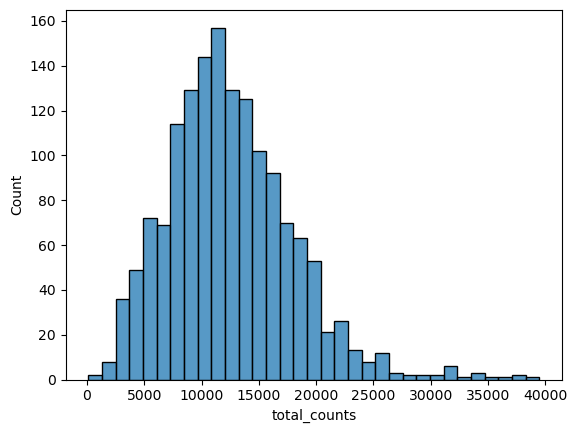

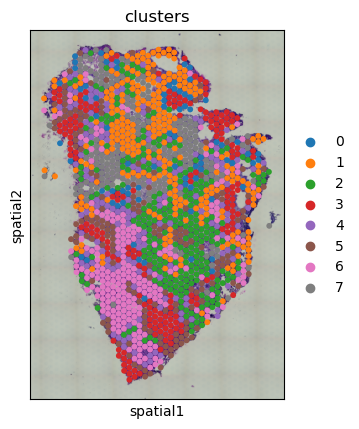

In [31]:
sys.path.append("/Users/lingyi/Documents/spatial/colocalization/functions")
import tools
importlib.reload(tools)
proc = tools.spatialTool()

dataset_name = "GSE210616_breast_spatial"
sampleID = "GSM6433609_120B"


folder = f"/Volumes/T7/datasets/{dataset_name}/raw/{sampleID}"
# if not os.path.isdir(folder):
#     print(f"⚠️ Folder not found, skipping: {folder}")
#     continue

proc = tools.spatialTool()
adata = proc.dataprocess(folder, skip_qc=False)


In [32]:
# Define gene signatures
aCAF = ['COL11A1']# consider the late stage only 
# immune_cells = ['MS4A1', 'CCL19', 'TCF7', 'SELL', 'GZMK']# non-exhaustive 
immune_cells = ['GZMA', 'CD8A',  'GZMK', 'CCL19', 'MS4A1']
tumor_epithelial = ['EPCAM', 'KRT8', 'KRT18', 'KRT19', 'ESR1', 'ERBB2']

adata.obs['aCAF_score'] = np.array(adata[:, aCAF].X.mean(axis=1)).flatten()
adata.obs['immune_score'] = np.array(adata[:, immune_cells].X.mean(axis=1)).flatten()
adata.obs['tumor_score'] = np.array(adata[:, tumor_epithelial].X.mean(axis=1)).flatten()


In [33]:
coords = adata.obsm['spatial_um']

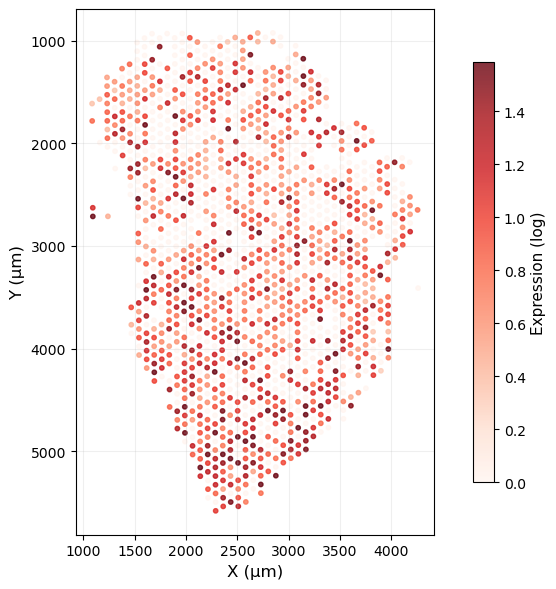


=== CD3D Expression Statistics ===
  Mean: 0.5839, Median: 0.6098
  Min: 0.0000, Max: 2.2801
  Cells expressing (>0): 925 (61.8%)


In [34]:
# Visualize single gene expression
gene = "CD3D"  

gene_expr = np.array(adata[:, gene].X.toarray()).flatten()

fig, ax = plt.subplots(figsize=(8, 6))

# Calculate vmax using 95th percentile
vmax = np.percentile(gene_expr[gene_expr > 0], 95) if (gene_expr > 0).any() else gene_expr.max()

# Create scatter plot
sc = ax.scatter(coords[:, 0], coords[:, 1], 
                s=10, c=gene_expr, cmap='Reds', alpha=0.8, vmin=0, vmax=vmax)

ax.set_aspect("equal")
ax.invert_yaxis()  # Invert Y-axis to match sc.pl.spatial
ax.set_xlabel("X (μm)", fontsize=12)
ax.set_ylabel("Y (μm)", fontsize=12)

cbar = plt.colorbar(sc, ax=ax, shrink=0.8)
cbar.set_label('Expression (log)', fontsize=11)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# Print expression statistics
print(f"\n=== {gene} Expression Statistics ===")
print(f"  Mean: {gene_expr.mean():.4f}, Median: {np.median(gene_expr):.4f}")
print(f"  Min: {gene_expr.min():.4f}, Max: {gene_expr.max():.4f}")
print(f"  Cells expressing (>0): {(gene_expr > 0).sum()} ({100*(gene_expr > 0).sum()/len(gene_expr):.1f}%)")


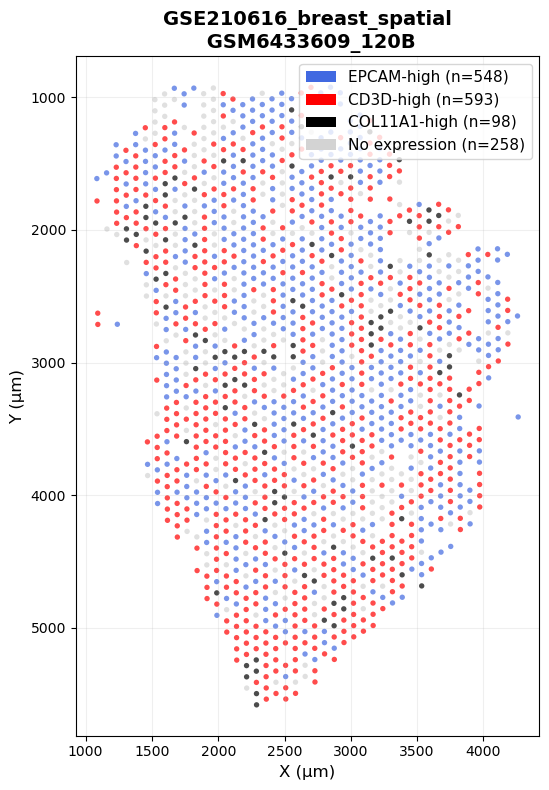


=== Cell Type Assignment Statistics ===
Total cells: 1497
  EPCAM-high: 548 (36.6%)
  CD3D-high: 593 (39.6%)
  COL11A1-high: 98 (6.5%)
  No expression: 258 (17.2%)


In [35]:
# Visualize three genes with cell type assignment (dominant gene)
# ===== USER CONFIGURATION =====
genes = ['EPCAM', 'CD3D', 'COL11A1']  # Modify this list to change genes
colors = ['royalblue', 'red', 'black']      # Corresponding colors
# ==============================

fig, ax = plt.subplots(figsize=(10, 8))

# Create color map
color_map = {gene: color for gene, color in zip(genes, colors)}

# Extract expression for all genes
gene_expressions = {}
for gene in genes:
    gene_expressions[gene] = np.array(adata[:, gene].X.toarray()).flatten()

# Stack expressions and find dominant gene for each cell
expr_matrix = np.stack([gene_expressions[gene] for gene in genes], axis=1)  # Shape: (n_cells, n_genes)
dominant_gene_idx = np.argmax(expr_matrix, axis=1)  # Index of max expression per cell

# Filter cells: only assign if expression > 0
has_expression = np.max(expr_matrix, axis=1) > 0

# Create color array for each cell
cell_colors = []
cell_labels = []
for i in range(len(coords)):
    if has_expression[i]:
        gene = genes[dominant_gene_idx[i]]
        cell_colors.append(color_map[gene])
        cell_labels.append(gene)
    else:
        cell_colors.append('lightgray')
        cell_labels.append('No expression')

# Plot cells colored by dominant gene
ax.scatter(coords[:, 0], coords[:, 1], 
           s=15, c=cell_colors, alpha=0.7, edgecolors='none')

ax.set_aspect("equal")
ax.invert_yaxis()  # Invert Y-axis to match sc.pl.spatial
ax.set_xlabel("X (μm)", fontsize=12)
ax.set_ylabel("Y (μm)", fontsize=12)
ax.set_title(f"{dataset_name}\n {sampleID}", 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.2)

# Create legend
from matplotlib.patches import Patch
legend_elements = []
for gene, color in zip(genes, colors):
    count = sum([1 for l in cell_labels if l == gene])
    legend_elements.append(Patch(facecolor=color, label=f'{gene}-high (n={count})'))
no_expr = sum([1 for l in cell_labels if l == "No expression"])
legend_elements.append(Patch(facecolor='lightgray', label=f'No expression (n={no_expr})'))

ax.legend(handles=legend_elements, loc='upper right', frameon=True, fontsize=11)

plt.tight_layout()
plt.show()

# Print statistics
print(f"\n=== Cell Type Assignment Statistics ===")
print(f"Total cells: {len(coords)}")
for gene in genes:
    count = sum([1 for l in cell_labels if l == gene])
    pct = 100 * count / len(coords)
    print(f"  {gene}-high: {count} ({pct:.1f}%)")
print(f"  No expression: {no_expr} ({100*no_expr/len(coords):.1f}%)")



=== T cells (CD3D) ===
  EPCAM: 548 (36.6%)
  COL11A1: 155 (10.4%)
  CD3D: 536 (35.8%)

=== CD8+ T cells (CD8A) ===
  EPCAM: 606 (40.5%)
  COL11A1: 172 (11.5%)
  CD8A: 404 (27.0%)

=== Tregs (FOXP3) ===
  EPCAM: 684 (45.7%)
  COL11A1: 192 (12.8%)
  FOXP3: 35 (2.3%)

=== Memory T (TCF7) ===
  EPCAM: 675 (45.1%)
  COL11A1: 187 (12.5%)
  TCF7: 122 (8.1%)

=== B cells (CD79A) ===
  EPCAM: 663 (44.3%)
  COL11A1: 161 (10.8%)
  CD79A: 206 (13.8%)

=== Macrophages (CD163) ===
  EPCAM: 350 (23.4%)
  COL11A1: 84 (5.6%)
  CD163: 956 (63.9%)

=== Naive T (CCR7) ===
  EPCAM: 685 (45.8%)
  COL11A1: 192 (12.8%)
  CCR7: 59 (3.9%)


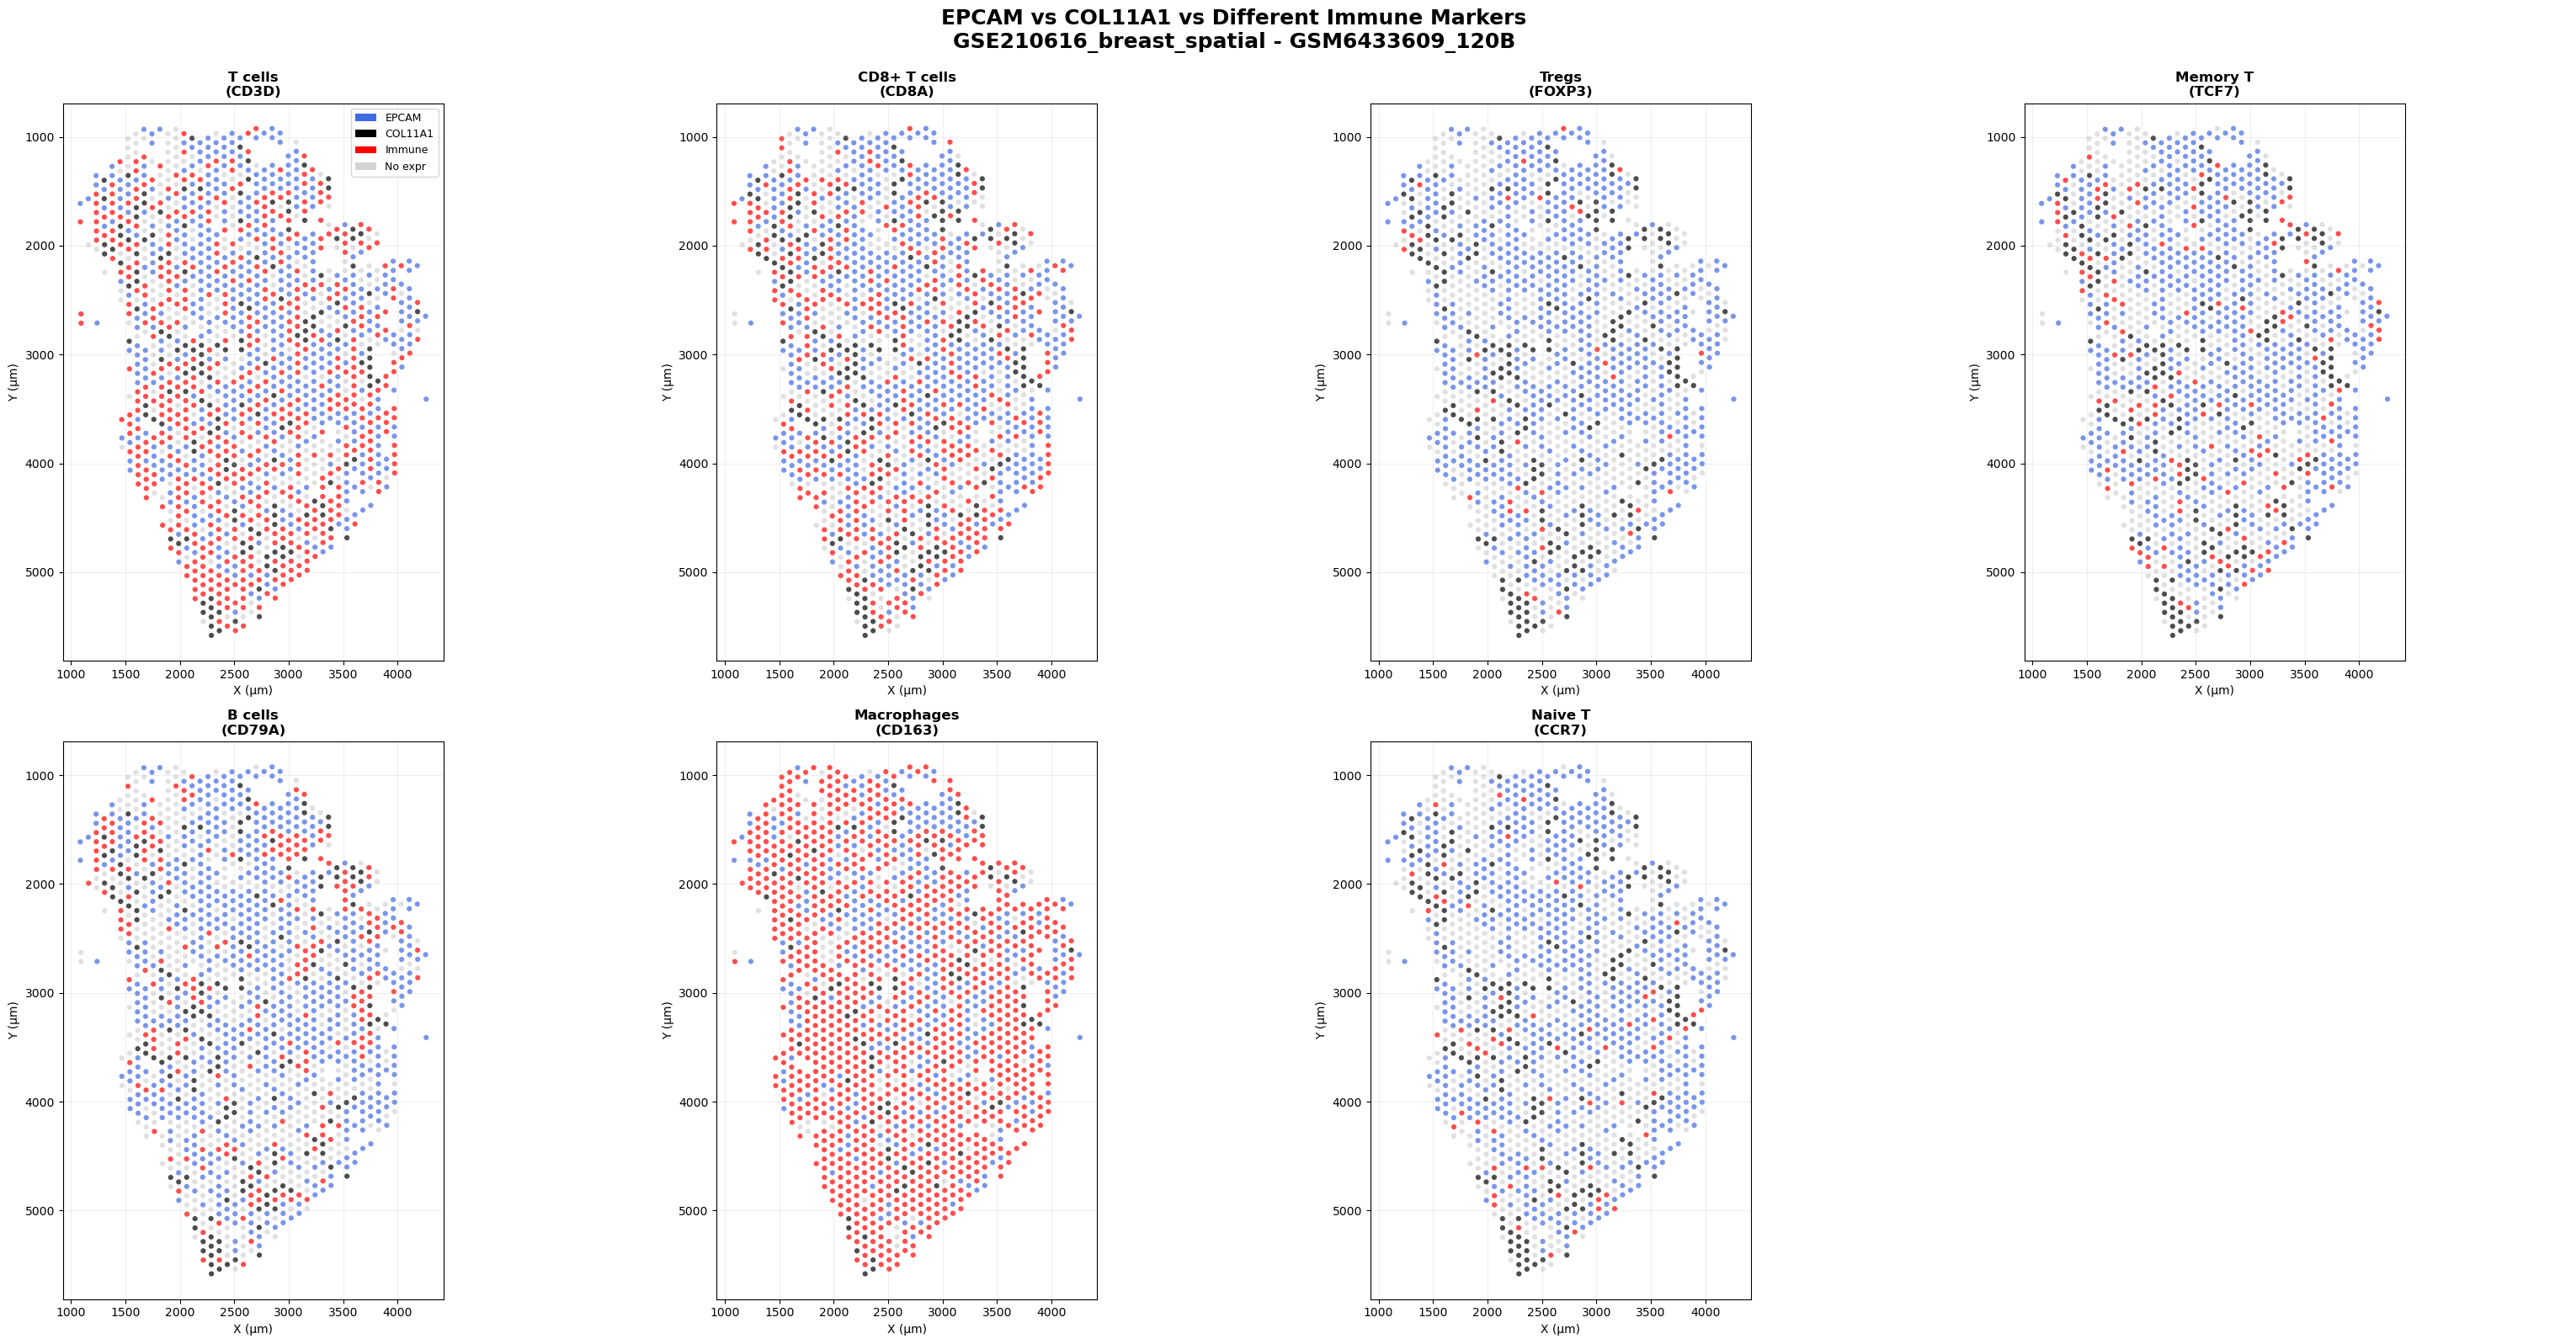

In [36]:
# Loop through different immune markers - display in two rows
immune_markers = [
    {'gene': 'CD3D', 'label': 'T cells'},
    {'gene': 'CD8A', 'label': 'CD8+ T cells'},
    {'gene': 'FOXP3', 'label': 'Tregs'},
    {'gene': 'TCF7', 'label': 'Memory T'},
    {'gene': 'CD79A', 'label': 'B cells'},
    {'gene': 'CD163', 'label': 'Macrophages'},
    {'gene': 'CCR7', 'label': 'Naive T'},
]

n_panels = len(immune_markers)
n_cols = 4  # 4 panels per row
n_rows = int(np.ceil(n_panels / n_cols))  # Calculate needed rows
fig, axes = plt.subplots(n_rows, n_cols, figsize=(8*n_cols, 8*n_rows))
axes = axes.flatten()  # Flatten to make indexing easier

for idx, marker in enumerate(immune_markers):
    ax = axes[idx]
    genes = ['EPCAM', 'COL11A1', marker['gene']]  
    colors = ['royalblue', 'black', 'red']
    
    color_map = {gene: color for gene, color in zip(genes, colors)}
    
    # Extract expression for all genes
    gene_expressions = {}
    for gene in genes:
        gene_expressions[gene] = np.array(adata[:, gene].X.toarray()).flatten()
    
    # Stack expressions and find dominant gene for each cell
    expr_matrix = np.stack([gene_expressions[gene] for gene in genes], axis=1)
    dominant_gene_idx = np.argmax(expr_matrix, axis=1)
    has_expression = np.max(expr_matrix, axis=1) > 0
    
    # Create color array for each cell
    cell_colors = []
    cell_labels = []
    for i in range(len(coords)):
        if has_expression[i]:
            gene = genes[dominant_gene_idx[i]]
            cell_colors.append(color_map[gene])
            cell_labels.append(gene)
        else:
            cell_colors.append('lightgray')
            cell_labels.append('No expression')
    
    # Plot cells colored by dominant gene
    ax.scatter(coords[:, 0], coords[:, 1], s=20, c=cell_colors, alpha=0.7, edgecolors='none')
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.set_xlabel("X (μm)", fontsize=10)
    ax.set_ylabel("Y (μm)", fontsize=10)
    ax.set_title(f"{marker['label']}\n({marker['gene']})", fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.2)
    
    # Add legend only to first panel
    if idx == 0:
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='royalblue', label='EPCAM'),
            Patch(facecolor='black', label='COL11A1'),
            Patch(facecolor='red', label='Immune'),
            Patch(facecolor='lightgray', label='No expr')
        ]
        ax.legend(handles=legend_elements, loc='upper right', frameon=True, fontsize=9)
    
    # Print statistics for this panel
    print(f"\n=== {marker['label']} ({marker['gene']}) ===")
    for gene in genes:
        count = sum([1 for l in cell_labels if l == gene])
        print(f"  {gene}: {count} ({100*count/len(coords):.1f}%)")

# Hide unused subplots
for idx in range(n_panels, len(axes)):
    axes[idx].axis('off')

plt.suptitle(f"EPCAM vs COL11A1 vs Different Immune Markers\n{dataset_name} - {sampleID}", 
             fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()